<a href="https://colab.research.google.com/github/shaevitz/MOL518-Intro-to-Data-Analysis/blob/main/Lecture_16/MOL518_Lecture16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In colab run this cell first to setup the file structure!
%cd /content
!rm -rf MOL518-Intro-to-Data-Analysis

!git clone https://github.com/shaevitz/MOL518-Intro-to-Data-Analysis.git
%cd MOL518-Intro-to-Data-Analysis/Lecture_16

# Lecture 16: Dimensionality reduction

This notebook introduces principal component analysis through examples inspired by molecular biology. Many biological datasets (particularly transcriptome measurements) involve a series of highly correlated measurements, and therefore are amenable to dimensionality reduction.

There are several existing methods for dimensionality reduction. Today we will focus on the simplest and oldest method: Principal Component Analysis (PCA).

## Example 1: Penguin data

For today's class, we are going to use a simple dataset consisting of measurements of 344 individual penguins from Palmer Station, Antarctica.

A link to the original publication describing the data can be found [here](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0090081).

### Load the data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)

In [2]:
# Load the palmer penguins dataset, we are using the simple version for this class
penguins = sns.load_dataset("penguins")

## Exercise 1: Principal Component Analysis

Perform principle component analysis of the penguin data (bill length, bill depth, flipper length, body mass). You can find a link to the necessary documentation below:

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [3]:
!uv pip install scikit-learn

Using Python 3.13.7 environment at: /home/david/coursework/MOL518-Intro-to-Data-Analysis/.venv
Resolved 5 packages in 418ms                                         
Installed 3 packages in 113ms                               
 + joblib==1.5.3
 + scikit-learn==1.8.0
 + threadpoolctl==3.6.0


In [6]:
import sklearn

In [65]:
pca = sklearn.decomposition.PCA(n_components = 4)

In [66]:
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [67]:
penguins_clean = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna()

In [76]:
penguins[['bill_length_mm','bill_depth_mm']]

,bill_length_mm,bill_depth_mm
0,39.1,18.7
1,39.5,17.4
2,40.3,18.0
3,NaN,NaN
4,36.7,19.3
...,...,...
339,NaN,NaN
340,46.8,14.3
341,50.4,15.7
342,45.2,14.8


In [68]:
penguins_clean

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [69]:
penguins_pca = pca.fit(penguins_clean)

In [70]:
penguins_pca.components_

array([[ 4.05127931e-03, -1.16205086e-03,  1.52752045e-02,
         9.99874445e-01],
       [ 3.08489268e-01, -9.04433417e-02,  9.46786209e-01,
        -1.58192151e-02],
       [ 9.44830770e-01,  1.44317360e-01, -2.94052076e-01,
         8.31740783e-04],
       [-1.10058051e-01,  9.85388833e-01,  1.29984301e-01,
        -3.94638476e-04]])

In [71]:
penguins_pca.explained_variance_ratio_

array([9.99891315e-01, 8.01178384e-05, 2.49247359e-05, 3.64257040e-06])

In [72]:
penguins_transformed = penguins_pca.transform(penguins_clean)

In [64]:
penguins_transformed

array([[-4.52023209e+02, -1.33366364e+01,  1.14798019e+00],
       [-4.01949980e+02, -9.15269401e+00, -9.03734153e-02],
       [-9.51740904e+02,  8.26147557e+00, -2.35184450e+00],
       ...,
       [ 1.54840123e+03, -2.39957316e+00,  9.98962243e-01],
       [ 9.98297511e+02, -4.68961215e+00, -1.56098005e+00],
       [ 1.19830521e+03, -5.57434574e+00,  2.93963322e+00]],
      shape=(342, 3))

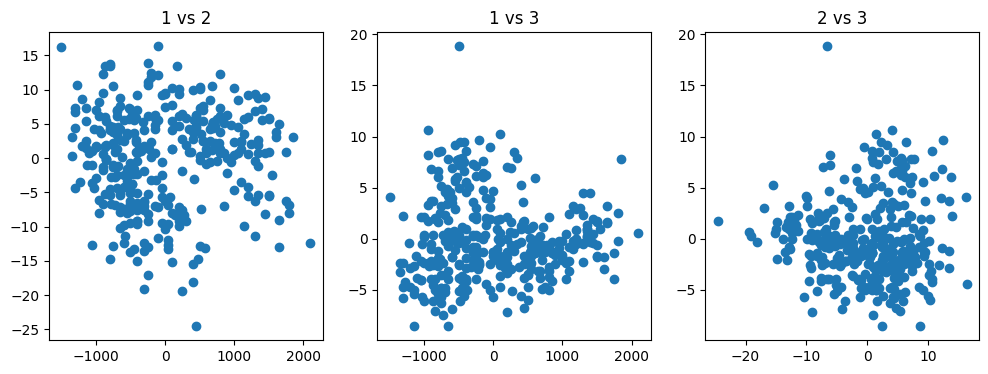

In [73]:
fig, ax = plt.subplots(1,3,figsize = (12,4))
ax[0].scatter(penguins_transformed[:,0], penguins_transformed[:,1])
ax[0].set_title('1 vs 2')
ax[1].scatter(penguins_transformed[:,0], penguins_transformed[:,2])
ax[1].set_title('1 vs 3')
ax[2].scatter(penguins_transformed[:,1], penguins_transformed[:,2])
ax[2].set_title('2 vs 3')
plt.show()

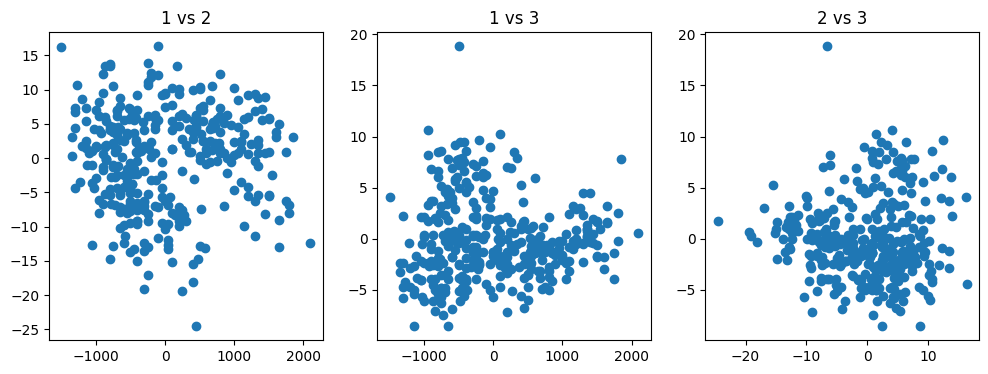

In [62]:
fig, ax = plt.subplots(1,3,figsize = (12,4))
ax[0].scatter(penguins_transformed[:,0], penguins_transformed[:,1])
ax[0].set_title('1 vs 2')
ax[1].scatter(penguins_transformed[:,0], penguins_transformed[:,2])
ax[1].set_title('1 vs 3')
ax[2].scatter(penguins_transformed[:,1], penguins_transformed[:,2])
ax[2].set_title('2 vs 3')
plt.show()

In [ ]:
# your code for Exercise 1 goes here



## Exercise 2: Plotting the PCs

Now, make biplots (scatter plots) of PC1 vs. PC2, PC1 vs. PC3, and PC2 vs. PC3. In a separate figure, make a scree plot of the principal components.

In [ ]:
# your code for Exercise 2 goes here

### Questions related to Exercise 2:

1. How much of the variance is explained by each of the principal components?

**[your answer goes here]**

2. What do the biplots look like? Is there anything funny about them? Where is this coming from?

**[your answer goes here]**

3. Is it possible to include other variables (species, island, sex) in the PCA analysis?

**[your answer goes here]**

4. How well do the PCA plots separate out the penguin species?

**[your answer goes here]**

## Bonus exercises

1. Is there a way to do the PCA so that the PCs are more similar in magnitude to one other?

**[your answer goes here]**

2. What is missing from the penguins dataset that would make PCA more informative?

**[your answer goes here]**

In [ ]:
# code for bonus exercises goes here